In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import skew, kurtosis, chi2_contingency

In [6]:
df = pd.read_csv('/Users/kyriakospapadopoulos/Desktop/University/Big Blue Data Academy/Personal/Assets/household_income.csv')

---
## Information from kaggle

**This synthetic dataset simulates various demographic and socioeconomic factors that influence annual household income. It can be used for exploratory data analysis, predictive modeling, and understanding the relationships between different features and income levels.**

### Features:
- **Age:** Age of the primary household member (18 to 70 years).
- **Education Level:** Highest education level attained (High School, Bachelor's, Master's, Doctorate).
- **Occupation:** Type of occupation (Healthcare, Education, Technology, Finance, Others).
- **Number of Dependents:** Number of dependents in the household (0 to 5).
- **Location:** Residential location (Urban, Suburban, Rural).
- **Work Experience:** Years of work experience (0 to 50 years).
- **Marital Status:** Marital status of the primary household member (Single, Married, Divorced).
- **Employment Status:** Employment status of the primary household member (Full-time, Part-time, Self-employed).
- **Household Size:** Total number of individuals living in the household (1 to 7).
- **Homeownership Status:** Homeownership status (Own, Rent).
- **Type of Housing:** Type of housing (Apartment, Single-family home, Townhouse).
- **Gender:** Gender of the primary household member (Male, Female).
- **Primary Mode of Transportation:** Primary mode of transportation used by the household member (Car, Public transit, Biking, Walking).
- **Annual Household Income:** Actual annual household income, derived from a combination of features with added noise. **Unit USD**

[Link to dataset](https://www.kaggle.com/datasets/stealthtechnologies/regression-dataset-for-household-income-analysis)

---

## Inspecting the dataset

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype 
---  ------                          --------------  ----- 
 0   Age                             10000 non-null  int64 
 1   Education_Level                 10000 non-null  object
 2   Occupation                      10000 non-null  object
 3   Number_of_Dependents            10000 non-null  int64 
 4   Location                        10000 non-null  object
 5   Work_Experience                 10000 non-null  int64 
 6   Marital_Status                  10000 non-null  object
 7   Employment_Status               10000 non-null  object
 8   Household_Size                  10000 non-null  int64 
 9   Homeownership_Status            10000 non-null  object
 10  Type_of_Housing                 10000 non-null  object
 11  Gender                          10000 non-null  object
 12  Primary_Mode_of_Transportation  10000 non-null 

In [12]:
df.head()

,Age,Education_Level,Occupation,Number_of_Dependents,Location,Work_Experience,Marital_Status,Employment_Status,Household_Size,Homeownership_Status,Type_of_Housing,Gender,Primary_Mode_of_Transportation,Income
0,56,Master's,Technology,5,Urban,21,Married,Full-time,7,Own,Apartment,Male,Public transit,72510
1,69,High School,Finance,0,Urban,4,Single,Full-time,7,Own,Apartment,Male,Biking,75462
2,46,Bachelor's,Technology,1,Urban,1,Single,Full-time,7,Own,Single-family home,Female,Car,71748
3,32,High School,Others,2,Urban,32,Married,Full-time,1,Own,Apartment,Female,Car,74520
4,60,Bachelor's,Finance,3,Urban,15,Married,Self-employed,4,Own,Townhouse,Male,Walking,640210


---
## Analysis of numerical features

In [15]:
numerical_columns = ['Age', 'Number_of_Dependents', 'Work_Experience', 'Household_Size', 'Income']

### Summary Statistics

In [18]:
df.describe()

,Age,Number_of_Dependents,Work_Experience,Household_Size,Income
count,10000.000000,10000.000000,10000.000000,10000.000000,1.000000e+04
mean,44.021700,2.527000,24.858800,3.989600,8.168382e+05
std,15.203998,1.713991,14.652622,2.010496,1.821089e+06
min,18.000000,0.000000,0.000000,1.000000,3.104400e+04
25%,31.000000,1.000000,12.000000,2.000000,6.844600e+04
50%,44.000000,3.000000,25.000000,4.000000,7.294300e+04
75%,57.000000,4.000000,37.000000,6.000000,3.506675e+05
max,70.000000,5.000000,50.000000,7.000000,9.992571e+06


### Box plots

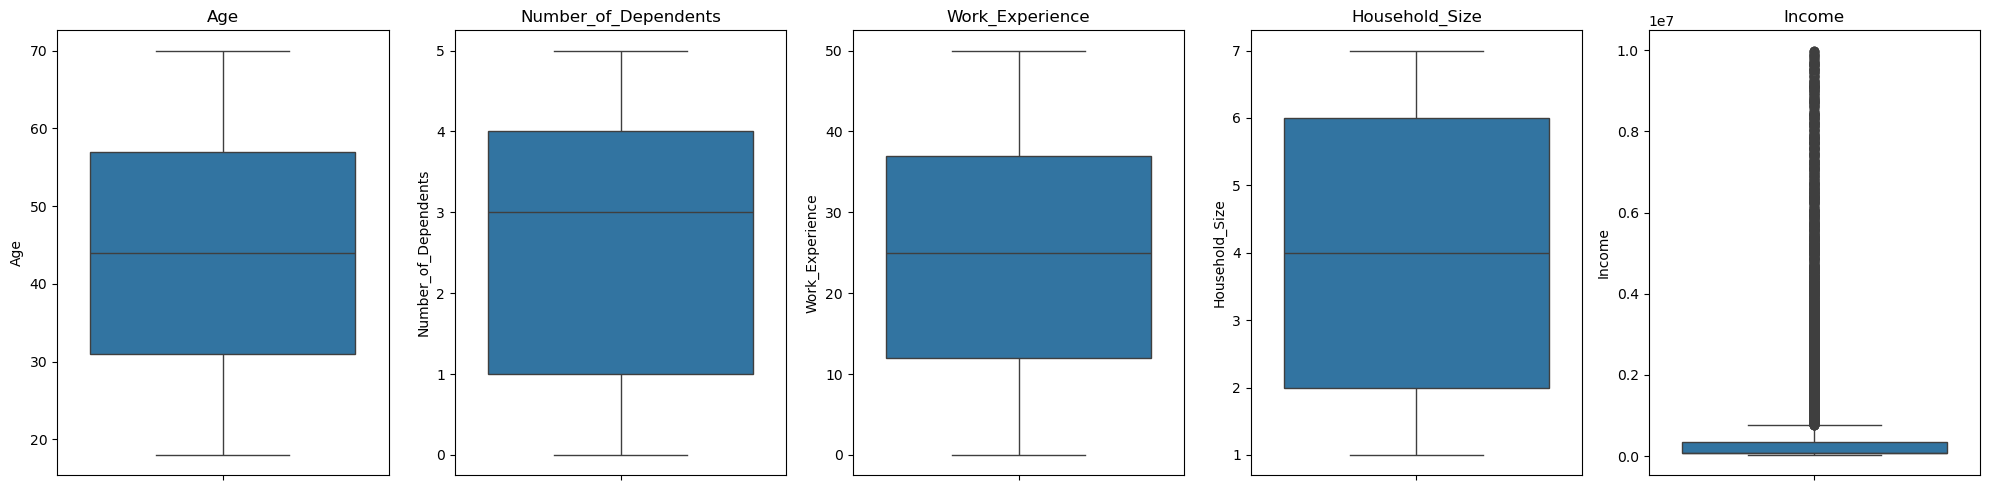

In [21]:
fig, axes = plt.subplots(nrows=1, ncols=len(numerical_columns), figsize=(20, 5))
for i, column in enumerate(numerical_columns):
    sns.boxplot(data=df, y=column, ax=axes[i])
    axes[i].set_title(column)
plt.tight_layout()
plt.show()

### Violin plots

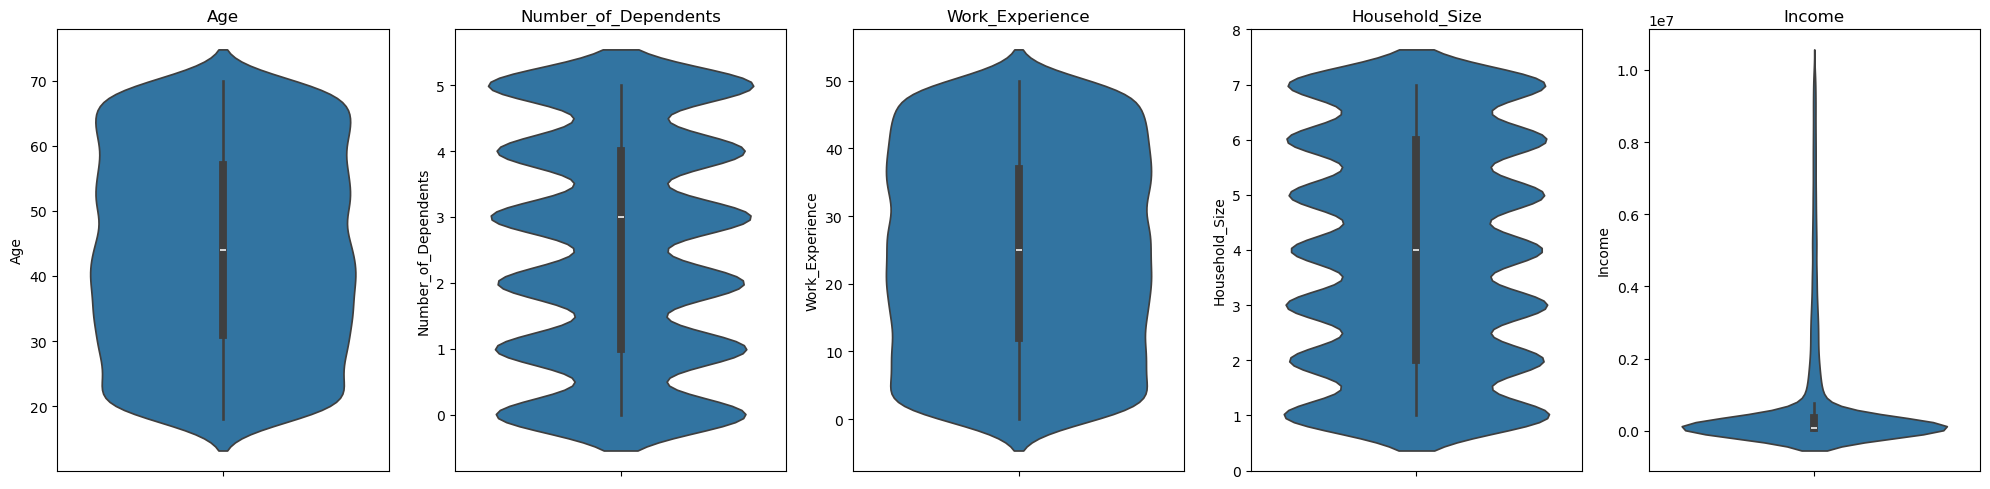

In [24]:
fig, axes = plt.subplots(nrows=1, ncols=len(numerical_columns), figsize=(20, 5))
for i, column in enumerate(numerical_columns):
    sns.violinplot(data=df, y=column, ax=axes[i])
    axes[i].set_title(column)
plt.tight_layout()
plt.show()

#### Initial observations:
- **Income** stands out due to its high standard deviation and large range, suggesting significant variance and possibly some extreme outliers. The box plot and violin plot both confirm that 'Income' is heavily skewed, consistent with the summary statistics. The violin plot also highlights the density of data around the lower end, with a long tail of outliers.
- **Age** appears fairly uniformly distributed, with a reasonable interquartile range (IQR). The violin plot suggests a slightly denser distribution around the middle age range but no significant skewness or outliers.
- **Number_of_Dependents** has a small range, indicating that most values are clustered around a few categories. The violin plot shows a uniform distribution across these categories, confirming that the data is well spread within the available options.
- **Work_Experience** shows a broad distribution with some spread but no extreme outliers. The violin plot suggests a fairly uniform distribution across the range of work experience, with no significant peaks or valleys, indicating a well-distributed variable.
- **Household_Size** appears to be well spread across its range, with no heavy skewness or clustering. The violin plot reinforces this observation by showing an even distribution across different household sizes, with no particular concentration in any specific range.

### Further analysis

In [28]:
# Calculate skewness and kurtosis for numerical variables
for column in numerical_columns:
    print(f'{column}:')
    print(f'Skewness: {skew(df[column]):.2f}')
    print(f'Kurtosis: {kurtosis(df[column]):.2f}')
    print('---------------------------------')

Age:
Skewness: 0.00
Kurtosis: -1.18
---------------------------------
Number_of_Dependents:
Skewness: -0.02
Kurtosis: -1.27
---------------------------------
Work_Experience:
Skewness: -0.00
Kurtosis: -1.19
---------------------------------
Household_Size:
Skewness: 0.00
Kurtosis: -1.26
---------------------------------
Income:
Skewness: 2.98
Kurtosis: 8.63
---------------------------------


### Addressing skewness and outliers in the 'Income' feature by apply a logorithmic transformation

In [31]:
# Apply log transformation to the Income variable
df['Income_log'] = np.log(df['Income'])

In [33]:
print('Income_log:')
print(f'Skewness: {skew(df["Income_log"]):.2f}')
print(f'Kurtosis: {kurtosis(df["Income_log"]):.2f}')

Income_log:
Skewness: 1.34
Kurtosis: 0.35


### Correlation Analysis

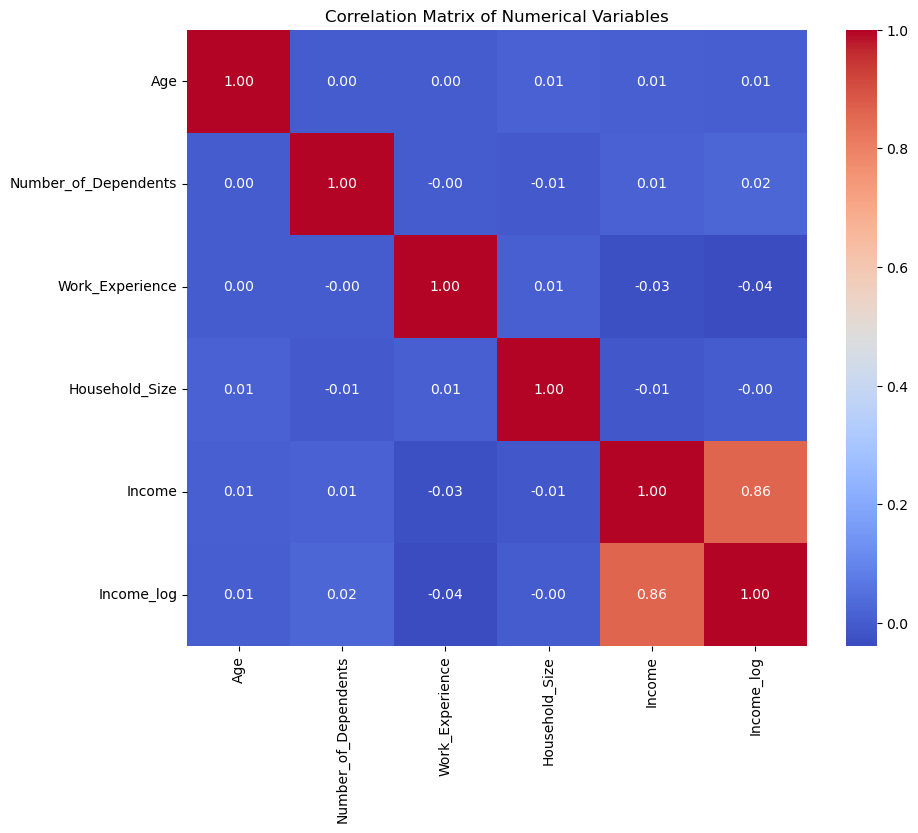

In [36]:
# Calculate correlation matrix
correlation_matrix = df[['Age', 'Number_of_Dependents', 'Work_Experience', 'Household_Size', 'Income', 'Income_log']].corr()

# Visualize the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Variables')
plt.show()

### Observations:
- The highest correlation in the matrix is between **Income** and **Income_log** (0.86), which is expected since one is derived from the other.
- All of the other variables in the dataset seem to have very low correlations with each other, with values close to 0. This suggests that there isn’t a strong linear relationship between most of these variables.
---

---
## Analysis of categorical features

In [40]:
non_numerical_columns = df.select_dtypes(include=['object']).columns

### Distribution Analysis

In [43]:
for column in non_numerical_columns:
    print(f'Distribution of {column}:')
    print(df[column].value_counts())
    print('-------------------------------')

Distribution of Education_Level:
Education_Level
Bachelor's     4058
High School    2959
Master's       2482
Doctorate       501
Name: count, dtype: int64
-------------------------------
Distribution of Occupation:
Occupation
Healthcare    3035
Technology    2407
Finance       1525
Others        1521
Education     1512
Name: count, dtype: int64
-------------------------------
Distribution of Location:
Location
Urban       7037
Suburban    1951
Rural       1012
Name: count, dtype: int64
-------------------------------
Distribution of Marital_Status:
Marital_Status
Married     5136
Single      3900
Divorced     964
Name: count, dtype: int64
-------------------------------
Distribution of Employment_Status:
Employment_Status
Full-time        5004
Part-time        3016
Self-employed    1980
Name: count, dtype: int64
-------------------------------
Distribution of Homeownership_Status:
Homeownership_Status
Own     6018
Rent    3982
Name: count, dtype: int64
-------------------------------
D

#### Bar charts

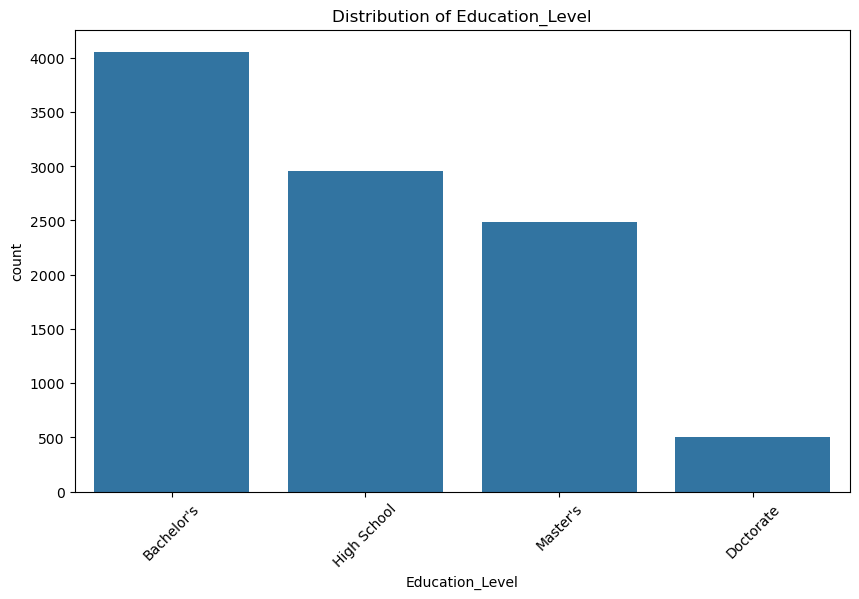

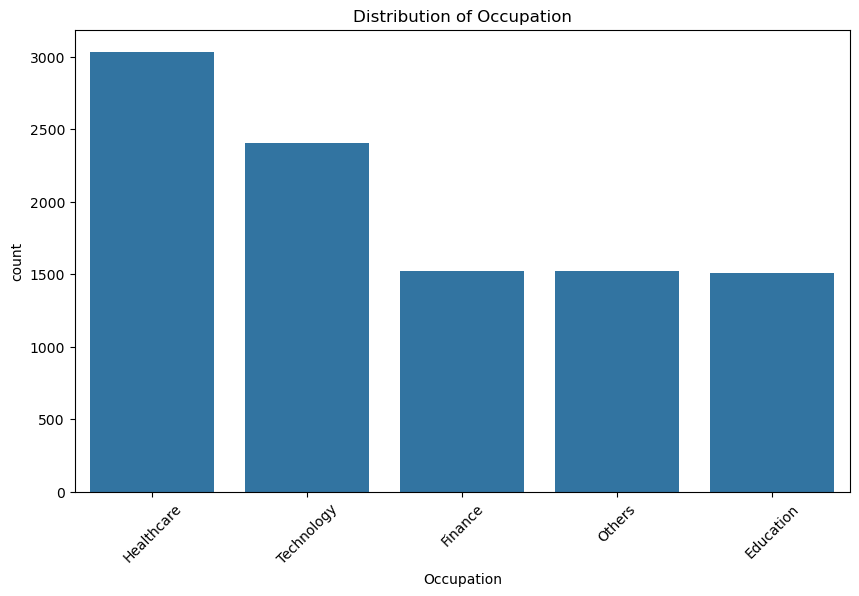

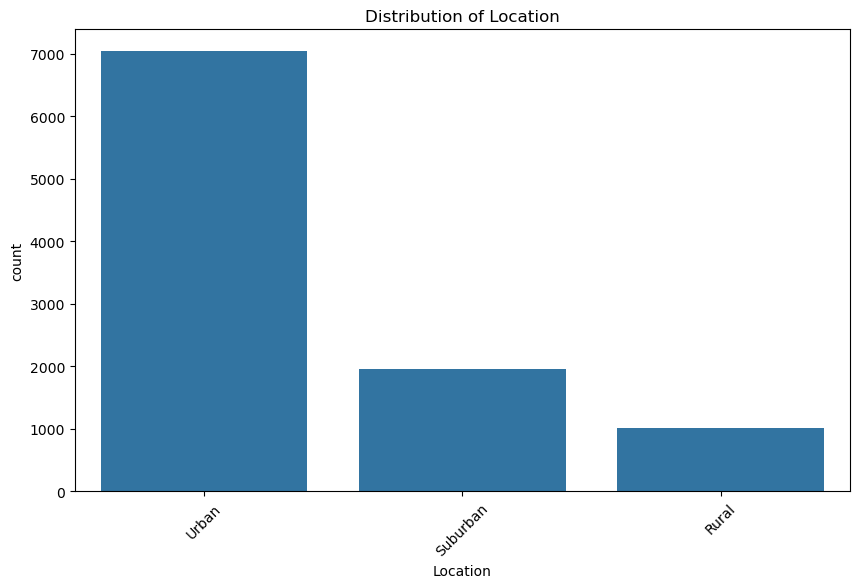

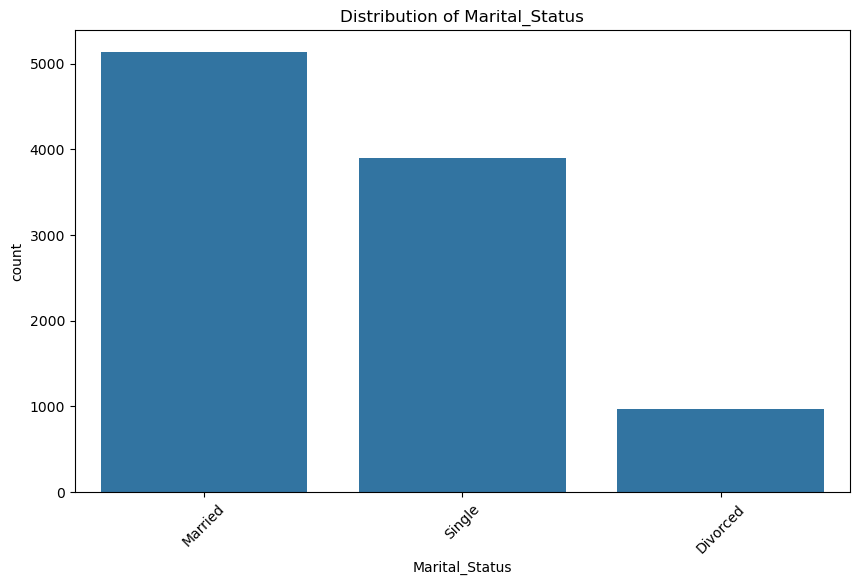

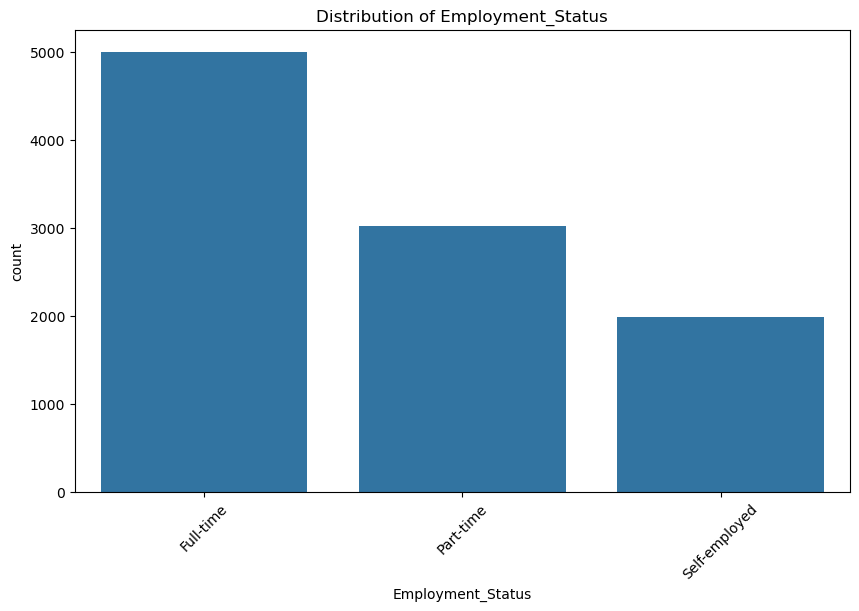

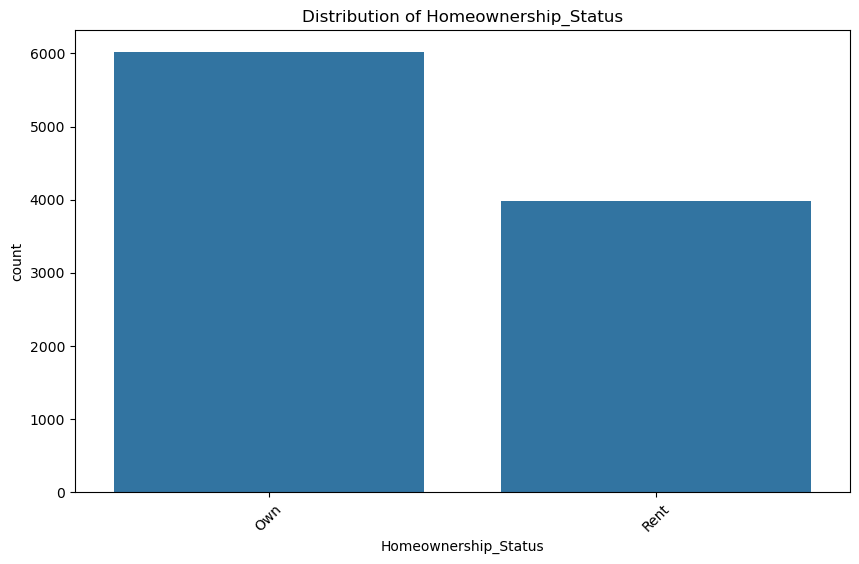

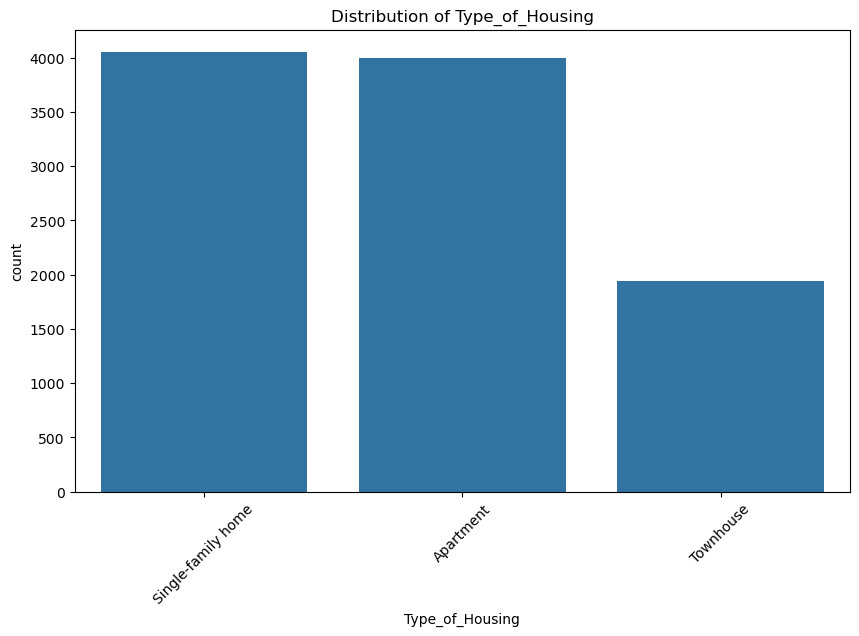

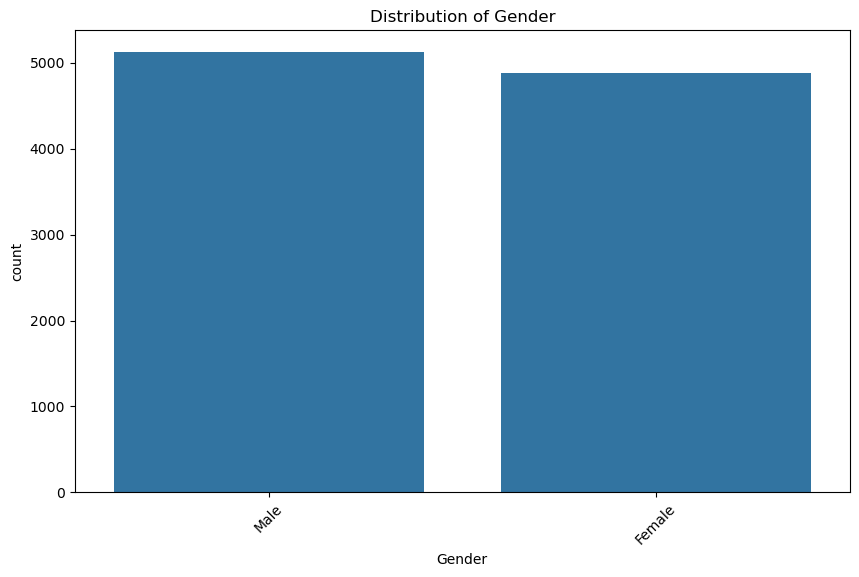

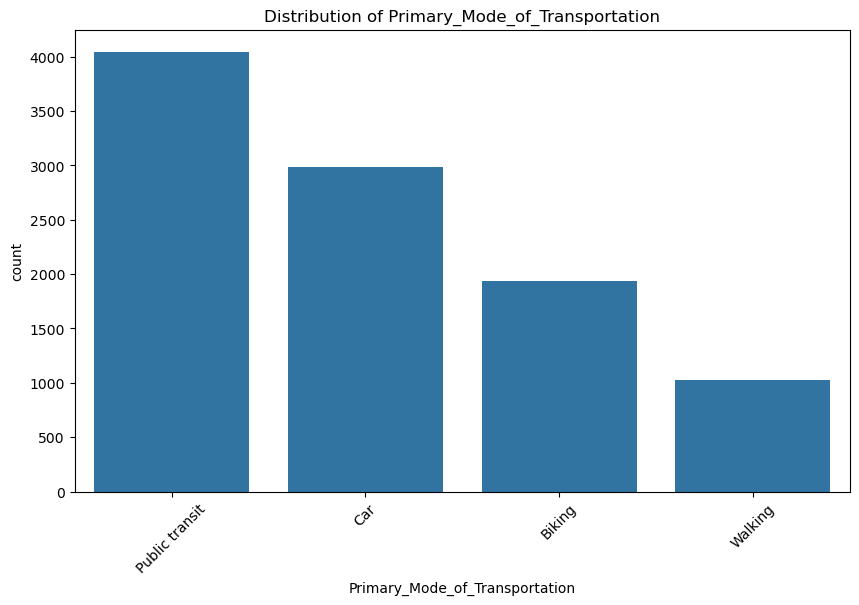

In [46]:
for column in non_numerical_columns:
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df, x=column, order=df[column].value_counts().index)
    plt.title(f'Distribution of {column}')
    plt.xticks(rotation=45)
    plt.show()

### Cramer's V Heatmap

In [55]:
def cramers_v(contingency_table):
    chi2, _, _, _ = chi2_contingency(contingency_table)
    n = contingency_table.sum().sum()
    return np.sqrt(chi2 / (n * (min(contingency_table.shape) - 1)))

def cramers_v_matrix(df, cat_columns):
    cramers_v_matrix = pd.DataFrame(index=non_numerical_columns, columns=non_numerical_columns)
    for col1 in non_numerical_columns:
        for col2 in non_numerical_columns:
            if col1 != col2:
                contingency_table = pd.crosstab(df[col1], df[col2])
                cramers_v_matrix.loc[col1, col2] = cramers_v(contingency_table)
            else:
                cramers_v_matrix.loc[col1, col2] = 1
    return cramers_v_matrix.astype(float)

In [57]:
cramers_v_df = cramers_v_matrix(df, non_numerical_columns)

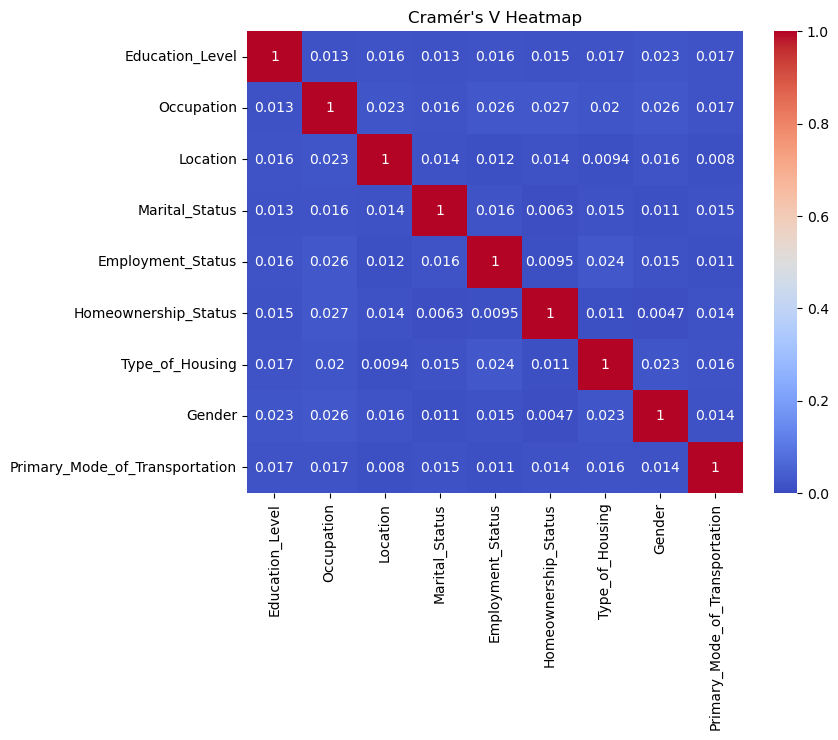

In [59]:
plt.figure(figsize=(8, 6))
sns.heatmap(cramers_v_df, annot=True, cmap='coolwarm', vmin=0, vmax=1)
plt.title("Cramér's V Heatmap")
plt.show()

### Observasions:
- **Distribution:** The categorical features in the dataset have moderate cardinality, with the number of unique categories ranging from 2 to 5.
- **Correlations:** The Cramér’s V heatmap showed very low correlations between categorical features, indicating that they are mostly independent. This suggests that there is little risk of multicollinearity when encoding these variables.
---